# Part 2 — Ethan Zheng: Topological Analysis
CASB 185 / CaSB 185 — Cell Mates Group Project

**Deliverables**
1. Rebuild lookup and graph from Notebook 1 (self-contained)
2. Steepest-ascent basin assignment with memoisation + path compression
3. Basin statistics — how many peaks, size distribution
4. Ranked refuge table — top-20 peaks by basin size
5. Visualisations — basin size bar chart + drug-composition heatmap
6. Pickle `basins` dict for Notebook 3

In [30]:
import json
import pickle
import re
import statistics
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import networkx as nx
import numpy as np
import pandas as pd

## 1. Locate data

In [31]:
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / "data" / "Raw Data and Growth Rate").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError("Could not locate project root containing data/Raw Data and Growth Rate/")

INPUT_DIR  = (PROJECT_ROOT / "data" / "Raw Data and Growth Rate" /
              "Interaction Calculation" / "Data" / "Data" / "input")
OUTPUT_DIR = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

assert INPUT_DIR.is_dir(), f"input/ folder not found: {INPUT_DIR}"
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"INPUT_DIR    = {INPUT_DIR}")
print(f"OUTPUT_DIR   = {OUTPUT_DIR}")

PROJECT_ROOT = C:\Users\lukes\Downloads\CSBIO185_cell_mates
INPUT_DIR    = C:\Users\lukes\Downloads\CSBIO185_cell_mates\data\Raw Data and Growth Rate\Interaction Calculation\Data\Data\input
OUTPUT_DIR   = C:\Users\lukes\Downloads\CSBIO185_cell_mates\output


## 2. Rebuild lookup and graph

Consolidated from Notebook 1 so this notebook runs standalone — no kernel-state dependency.

In [32]:
DOSE_LABEL_RE = re.compile(
    r"^([A-Z]{3})\d([A-Z]{3})\d([A-Z]{3})\d([A-Z]{3})\d([A-Z]{3})\d$"
)
DOSE_LABEL_RE = re.compile(
    r"^([A-Z]{3})(\d)([A-Z]{3})(\d)([A-Z]{3})(\d)([A-Z]{3})(\d)([A-Z]{3})(\d)$"
)

@dataclass
class DoseBlock:
    label: str
    doses: dict
    fitness: dict


def parse_input_file(path):
    raw    = path.read_text().replace("\n", "")
    fields = raw.split(",")
    blocks, focal_drugs, i = [], None, 0
    while i < len(fields):
        tok = fields[i].strip()
        if not tok:
            i += 1; continue
        m = DOSE_LABEL_RE.match(tok)
        if not m:
            i += 1; continue
        drugs  = [m.group(2 * k + 1) for k in range(5)]
        levels = [int(m.group(2 * k + 2)) for k in range(5)]
        if focal_drugs is None:
            focal_drugs = drugs
        header = fields[i + 1 : i + 32]
        try:
            values = [float(v) for v in fields[i + 32 : i + 63]]
        except ValueError:
            i += 1; continue
        fit_map = {frozenset(h.split("+")): v for h, v in zip(header, values)}
        blocks.append(DoseBlock(label=tok,
                                doses=dict(zip(drugs, levels)),
                                fitness=fit_map))
        i += 63
    if focal_drugs is None:
        raise ValueError(f"No dose blocks found in {path}")
    return focal_drugs, blocks


def build_lookup(parsed):
    bucket = defaultdict(list)
    for _, _, blocks in parsed:
        for b in blocks:
            for subset, fit in b.fitness.items():
                dose_vec = tuple(sorted((d, b.doses[d]) for d in subset))
                bucket[(subset, dose_vec)].append(fit)
    lookup = defaultdict(dict)
    for (subset, dose_vec), vals in bucket.items():
        lookup[subset][dose_vec] = {
            "mean": statistics.mean(vals),
            "sd":   statistics.stdev(vals) if len(vals) > 1 else 0.0,
            "n":    len(vals),
        }
    return {k: dict(v) for k, v in lookup.items()}


def build_graph(lookup):
    G = nx.DiGraph()
    G.add_node("EMPTY", subset=frozenset(), size=0,
               fitness=100.0, dose=(), sd=0.0, n=1)

    for subset, dose_dict in lookup.items():
        for dose_vec, rec in dose_dict.items():
            nid = "+".join(f"{d}{lvl}" for d, lvl in dose_vec)
            if not nid:
                continue
            G.add_node(nid, subset=subset, size=len(subset),
                       fitness=rec["mean"], dose=dose_vec,
                       sd=rec["sd"], n=rec["n"])

    by_size = {}
    for nid, data in G.nodes(data=True):
        by_size.setdefault(data["size"], []).append((nid, data))

    for size in sorted(by_size):
        if size + 1 not in by_size:
            continue
        for src_id, src in by_size[size]:
            for tgt_id, tgt in by_size[size + 1]:
                if not src["subset"].issubset(tgt["subset"]):
                    continue
                if src["subset"]:
                    src_dose = dict(src["dose"])
                    tgt_dose = dict(tgt["dose"])
                    if any(src_dose[d] != tgt_dose[d] for d in src["subset"]):
                        continue
                added = next(iter(tgt["subset"] - src["subset"]))
                grad  = tgt["fitness"] - src["fitness"]
                G.add_edge(src_id, tgt_id, direction="add",    drug=added, gradient=grad)
                G.add_edge(tgt_id, src_id, direction="remove", drug=added, gradient=-grad)
    return G

In [33]:
files  = sorted(INPUT_DIR.glob("*.csv"))
parsed = [(f, *parse_input_file(f)) for f in files]
lookup = build_lookup(parsed)
G      = build_graph(lookup)

print(f"Graph rebuilt: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Graph rebuilt: 21,067 nodes, 191,568 edges


## 3. Steepest-ascent basin assignment

**Concept:** A local peak is a node where every adjacent node (add *or* remove one drug) has lower or equal fitness. The basin of attraction of a peak is all nodes that lead to it when always stepping uphill.

**Why `G.successors` covers both directions:** Part 1 adds both an `add` edge and a `remove` edge for every adjacent pair, so `G.successors(node)` already returns every neighbouring node regardless of drug count.

**Path compression:** We record the walk path. Once the terminal peak is resolved we backfill `memo[node] = peak` for the entire path in one pass — every node is memoised exactly once, giving O(N) total instead of O(N²).

**Iterative, not recursive:** With ~21 K nodes the walk could exceed Python's default recursion limit of 1 000.

In [34]:
memo: dict = {}   # node_id -> peak_id


def find_peak(start_id: str) -> str:
    path: list = []
    current = start_id

    while current not in memo:
        path.append(current)
        fitness_current = G.nodes[current]["fitness"]

        best_nbr = None
        best_fit = fitness_current
        for nbr in G.successors(current):
            nbr_fit = G.nodes[nbr]["fitness"]
            if nbr_fit > best_fit:
                best_fit = nbr_fit
                best_nbr = nbr
            elif nbr_fit == best_fit and best_nbr is not None and nbr < best_nbr:
                best_nbr = nbr   # tie-break by node-id string for reproducibility

        if best_nbr is None:
            # current is a local peak
            memo[current] = current
            for node in path:
                memo[node] = current
            return current

        current = best_nbr

    # hit an already-memoised node — backfill path
    peak = memo[current]
    for node in path:
        memo[node] = peak
    return peak


for node_id in G.nodes():
    find_peak(node_id)

n_peaks = len(set(memo.values()))
print(f"Nodes assigned : {len(memo):,}")
print(f"Distinct peaks : {n_peaks}")

Nodes assigned : 21,067
Distinct peaks : 664


## 4. Group nodes by terminal peak — basin statistics

In [41]:
basins: dict = defaultdict(list)
for node_id, peak_id in memo.items():
    basins[peak_id].append(node_id)
basins = dict(basins)

ranked_peaks = sorted(basins.items(), key=lambda kv: len(kv[1]), reverse=True)

print(f"Total peaks    : {len(ranked_peaks)}")
print(f"Largest basin  : {len(ranked_peaks[0][1]):,} nodes  ->  peak '{ranked_peaks[0][0]}'")
print(f"Smallest basin : {len(ranked_peaks[-1][1])} node(s)")
print(f"Median size    : {statistics.median(len(v) for v in basins.values()):.1f} nodes")
print()

peak_size_dist = defaultdict(list)
for peak_id, members in basins.items():
    n_drugs = G.nodes[peak_id]["size"]
    peak_size_dist[n_drugs].append(len(members))

print(f"{'Peak # drugs':<14} {'# peaks':>8} {'mean basin':>12} {'max basin':>12}")
for nd in sorted(peak_size_dist):
    vals = peak_size_dist[nd]
    print(f"{nd:<14} {len(vals):>8} {statistics.mean(vals):>12.1f} {max(vals):>12,}")

with open("ranked_peaks.pkl",  "wb") as f:
    pickle.dump(ranked_peaks, f)
    
with open("basins.pkl",  "wb") as f:
    pickle.dump(basins, f)

Total peaks    : 664
Largest basin  : 3,186 nodes  ->  peak 'DOX3+TMP3'
Smallest basin : 1 node(s)
Median size    : 9.0 nodes

Peak # drugs    # peaks   mean basin    max basin
2                     6       1225.5        3,186
3                     1        854.0          854
4                    29         94.5          630
5                   628         16.1          288


## 5. Ranked refuge table — top 20 peaks

In [42]:
ALL_DRUGS = sorted({d for subset in lookup for d in subset})

rows = []
for rank, (peak_id, members) in enumerate(ranked_peaks[:20], start=1):
    nd  = G.nodes[peak_id]
    dv  = nd["dose"]
    composition = ", ".join(f"{d}x{lvl}" for d, lvl in dv) if dv else "— (no drugs)"
    frac = len(members) / G.number_of_nodes() * 100
    rows.append({
        "Rank"          : rank,
        "Peak"          : peak_id,
        "Basin size"    : len(members),
        "% of graph"    : round(frac, 2),
        "# drugs"       : nd["size"],
        "Fitness (mean)": round(nd["fitness"], 2),
        "SD"            : round(nd["sd"], 3),
        "Composition"   : composition,
    })

df_table = pd.DataFrame(rows)
df_table

with open("ALL_DRUGS.pkl",  "wb") as f:
    pickle.dump(ALL_DRUGS, f)

## 6. Visualisation A — Basin-size bar chart (all peaks, log scale)

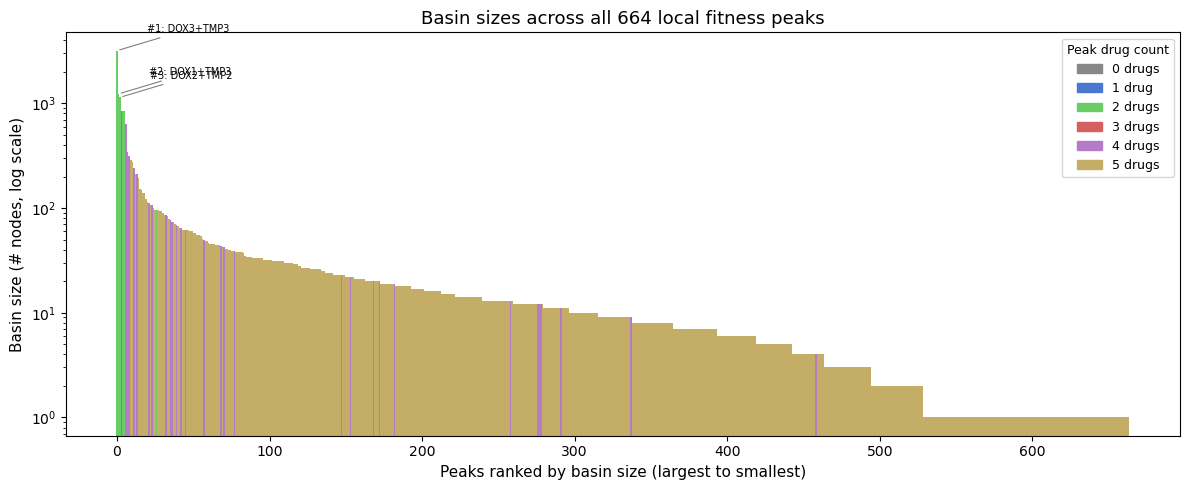

In [37]:
DRUG_COUNT_COLORS = {
    0: "#888888",
    1: "#4878CF",
    2: "#6ACC65",
    3: "#D65F5F",
    4: "#B47CC7",
    5: "#C4AD66",
}

peak_ids    = [pk for pk, _ in ranked_peaks]
basin_sizes = [len(members) for _, members in ranked_peaks]
bar_colors  = [DRUG_COUNT_COLORS.get(G.nodes[pk]["size"], "#cccccc") for pk in peak_ids]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(peak_ids)), basin_sizes, color=bar_colors, width=1.0, linewidth=0)
ax.set_yscale("log")
ax.set_xlabel("Peaks ranked by basin size (largest to smallest)", fontsize=11)
ax.set_ylabel("Basin size (# nodes, log scale)", fontsize=11)
ax.set_title(f"Basin sizes across all {len(ranked_peaks)} local fitness peaks", fontsize=13)

legend_handles = [
    Patch(color=DRUG_COUNT_COLORS[k], label=f"{k} drug{'s' if k != 1 else ''}")
    for k in sorted(DRUG_COUNT_COLORS)
]
ax.legend(handles=legend_handles, title="Peak drug count",
          loc="upper right", fontsize=9, title_fontsize=9)

for rank_i in range(min(3, len(ranked_peaks))):
    offset = max(len(ranked_peaks) * 0.03, 1)
    ax.annotate(
        f"#{rank_i + 1}: {peak_ids[rank_i]}",
        xy=(rank_i, basin_sizes[rank_i]),
        xytext=(rank_i + offset, basin_sizes[rank_i] * 1.5),
        fontsize=7, arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "basin_size_distribution.png", dpi=150)
plt.show()

## 7. Visualisation B — Drug-composition heatmap for top-20 peaks

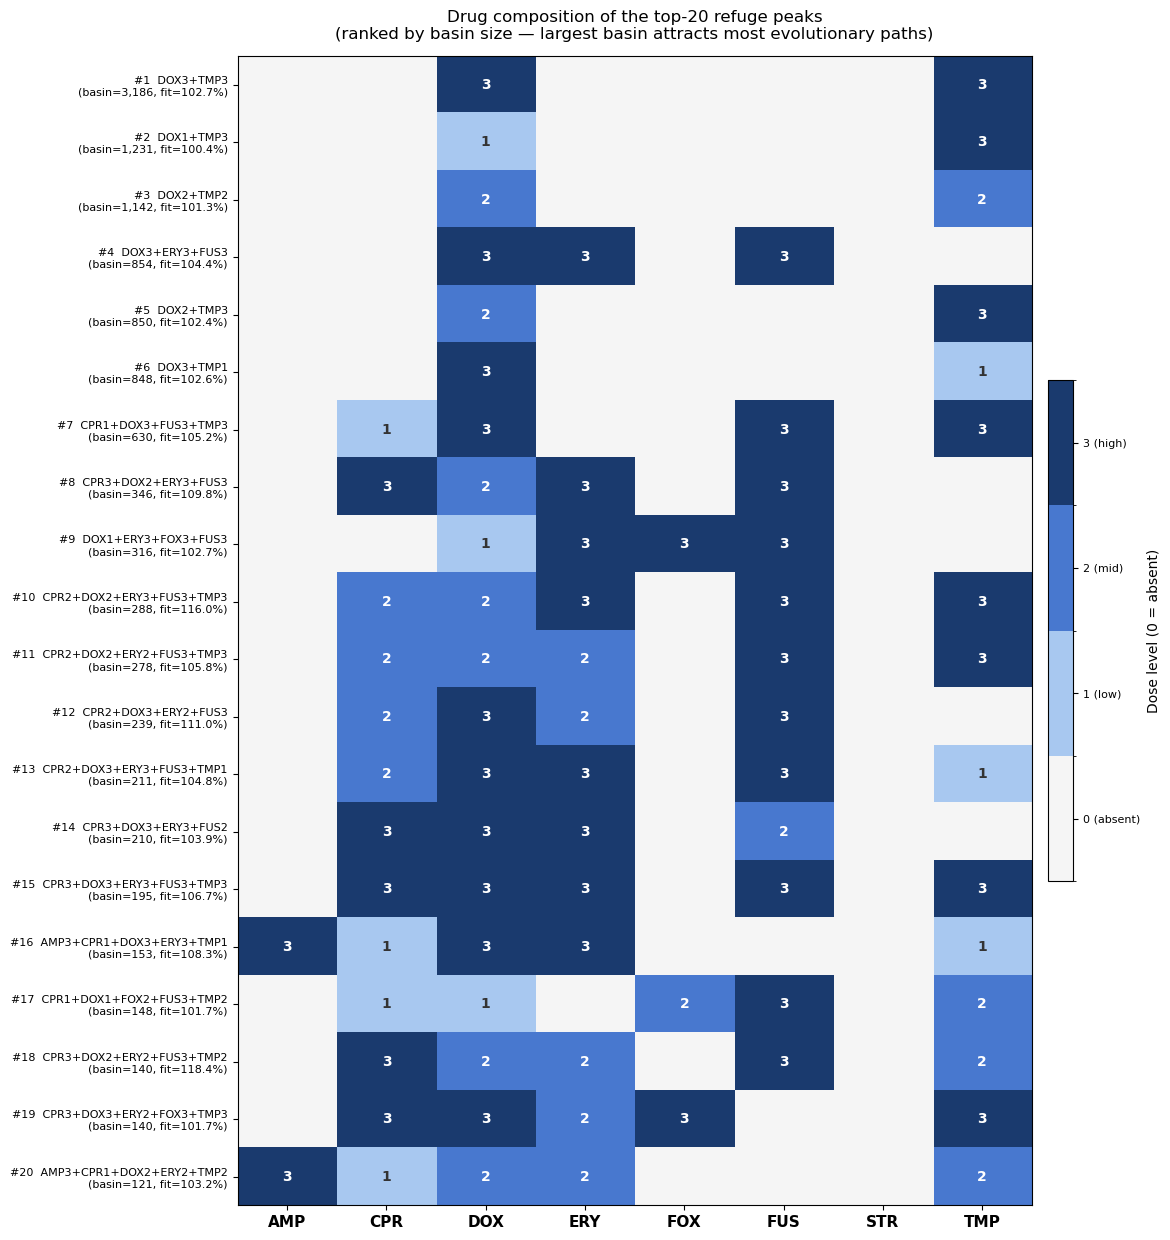

In [38]:
TOP_N = 20
top_peaks  = [pk for pk, _ in ranked_peaks[:TOP_N]]
top_labels = [
    f"#{i+1}  {pk}\n(basin={len(basins[pk]):,}, fit={G.nodes[pk]['fitness']:.1f}%)"
    for i, pk in enumerate(top_peaks)
]

mat = np.zeros((len(top_peaks), len(ALL_DRUGS)), dtype=float)
for r, pk in enumerate(top_peaks):
    dose_map = dict(G.nodes[pk]["dose"])
    for c, drug in enumerate(ALL_DRUGS):
        mat[r, c] = dose_map.get(drug, 0)

cmap_colors = ["#f5f5f5", "#a8c8f0", "#4878CF", "#1a3a6e"]
cmap   = mcolors.ListedColormap(cmap_colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(len(ALL_DRUGS) * 1.1 + 3, TOP_N * 0.55 + 1.5))
im = ax.imshow(mat, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(range(len(ALL_DRUGS)))
ax.set_xticklabels(ALL_DRUGS, fontsize=11, fontweight="bold")
ax.set_yticks(range(len(top_peaks)))
ax.set_yticklabels(top_labels, fontsize=8)

for r in range(len(top_peaks)):
    for c in range(len(ALL_DRUGS)):
        val = int(mat[r, c])
        if val > 0:
            ax.text(c, r, str(val), ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="white" if val >= 2 else "#333333")

cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], fraction=0.03, pad=0.02)
cbar.set_label("Dose level (0 = absent)", fontsize=10)
cbar.ax.set_yticklabels(["0 (absent)", "1 (low)", "2 (mid)", "3 (high)"], fontsize=8)

ax.set_title(
    f"Drug composition of the top-{TOP_N} refuge peaks\n"
    "(ranked by basin size — largest basin attracts most evolutionary paths)",
    fontsize=12, pad=12
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "refuge_composition_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Landscape summary

In [39]:
total_nodes    = G.number_of_nodes()
top_basin_frac = len(ranked_peaks[0][1]) / total_nodes * 100
top5_frac      = sum(len(basins[pk]) for pk, _ in ranked_peaks[:5]) / total_nodes * 100

print(f"Total nodes in graph        : {total_nodes:,}")
print(f"Total local peaks           : {len(ranked_peaks)}")
print(f"Largest basin coverage      : {top_basin_frac:.1f}% of all nodes")
print(f"Top-5 basins combined       : {top5_frac:.1f}% of all nodes")
print(f"#1 peak is EMPTY (no drugs) : {ranked_peaks[0][0] == 'EMPTY'}")

Total nodes in graph        : 21,067
Total local peaks           : 664
Largest basin coverage      : 15.1% of all nodes
Top-5 basins combined       : 34.5% of all nodes
#1 peak is EMPTY (no drugs) : False


## 9. Hand-off — pickle `basins` for Notebook 3

`basins` maps `peak_id (str)` → `list[node_id]`, sorted largest basin first.

Notebook 3 load snippet:
```python
import pickle
basins = pickle.load(open("output/basins.pkl", "rb"))
```

In [40]:
basins_sorted = dict(ranked_peaks)   # already sorted descending by basin size

out_path = OUTPUT_DIR / "basins.pkl"
with open(out_path, "wb") as fh:
    pickle.dump(basins_sorted, fh, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Pickled basins -> {out_path}")
print(f"  Keys   : {len(basins_sorted)} peaks (sorted largest basin first)")
print(f"  Values : list of node_id strings in each basin")

Pickled basins -> C:\Users\lukes\Downloads\CSBIO185_cell_mates\output\basins.pkl
  Keys   : 664 peaks (sorted largest basin first)
  Values : list of node_id strings in each basin
